In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

In [3]:
excercise = pd.read_csv(r'D:\Projects\DataScience\FitPredict\exercise.csv')
calories = pd.read_csv(r'D:\Projects\DataScience\FitPredict\calories.csv')

In [4]:
df = pd.merge(excercise, calories, on="User_ID")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
df.drop(columns=["User_ID"], inplace=True)

In [6]:
df["Gender"] = df["Gender"].map({"male": 1, "female": 0})

In [7]:
df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)
df["Intensity"] = df["Age"] * df["Heart_Rate"]
df["Effort"] = df["Duration"] * df["Heart_Rate"]

In [8]:
X = df.drop("Calories", axis=1)
y = df["Calories"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [13]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [14]:
print("Linear Regression:")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

print("\nDecision Tree Regressor:")
print("R2 Score:", r2_score(y_test, y_pred_dt)) 
print("MAE:", mean_absolute_error(y_test, y_pred_dt))

print("\nRandom Forest Regressor:")
print("R2 Score:", r2_score(y_test, y_pred_rf))     
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

Linear Regression:
R2 Score: 0.9886146206472801
MAE: 5.021771676404412

Decision Tree Regressor:
R2 Score: 0.9945551365929706
MAE: 3.0616666666666665

Random Forest Regressor:
R2 Score: 0.9983405295497514
MAE: 1.65483


In [15]:
joblib.dump(rf, "fitness_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

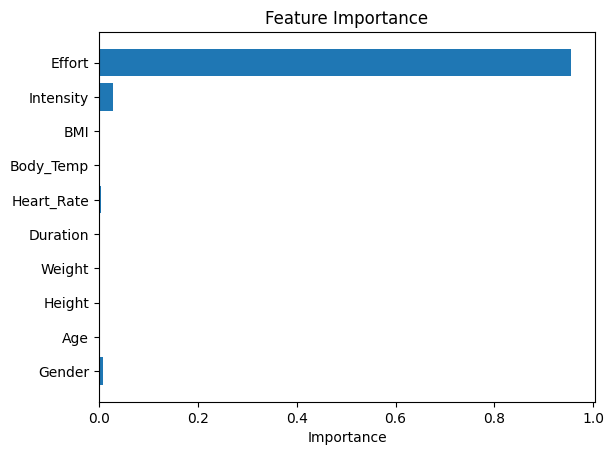

In [16]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()